=== Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         1080 non-null   datetime64[ns]
 1   Location                     1080 non-null   object        
 2   AQI                          1080 non-null   int64         
 3   PM2.5 (ug/m3)                1080 non-null   float64       
 4   PM10 (ug/m3)                 1080 non-null   float64       
 5   NO2 (ppb)                    1080 non-null   float64       
 6   SO2 (ppb)                    1080 non-null   float64       
 7   CO (ppm)                     1080 non-null   float64       
 8   O3 (ppb)                     1080 non-null   float64       
 9   Temperature (C)              1080 non-null   float64       
 10  Humidity (%)                 1080 non-null   float64       
 11  Wind Speed (km/h)  

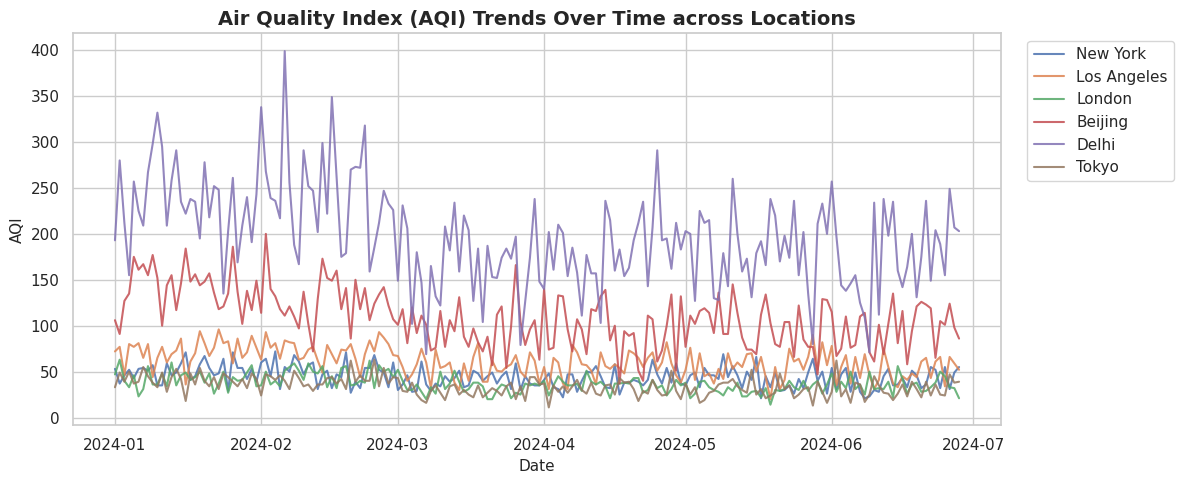

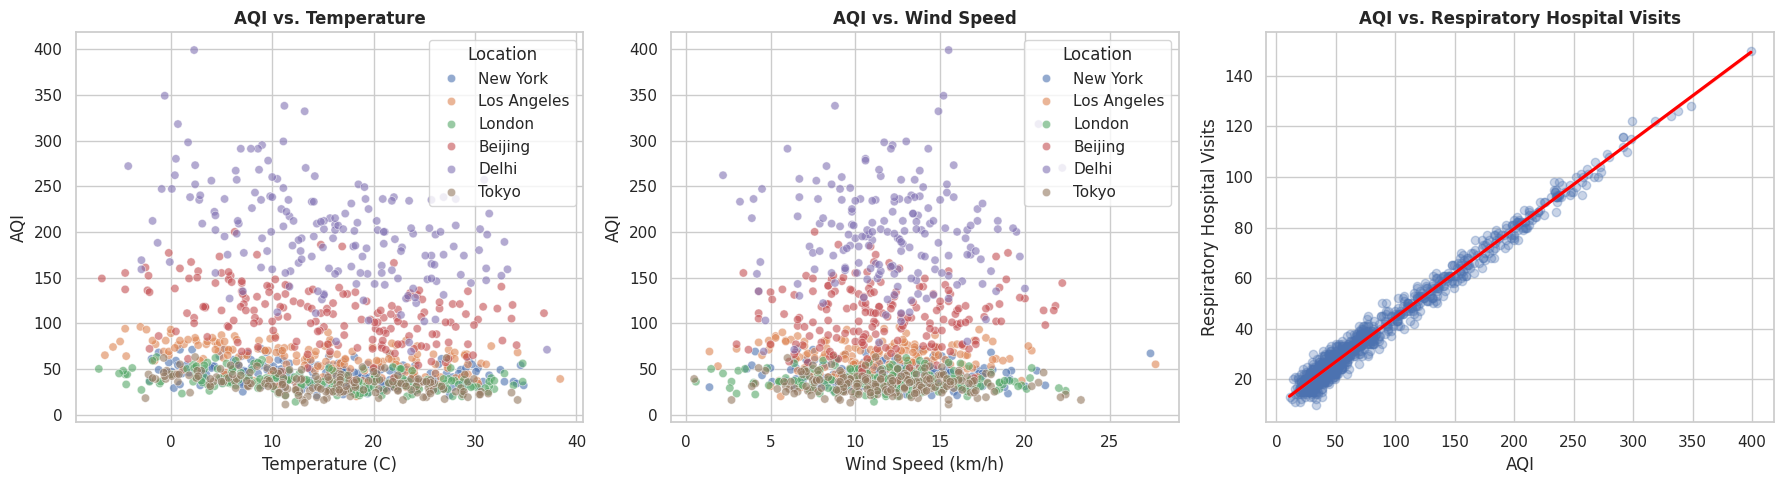

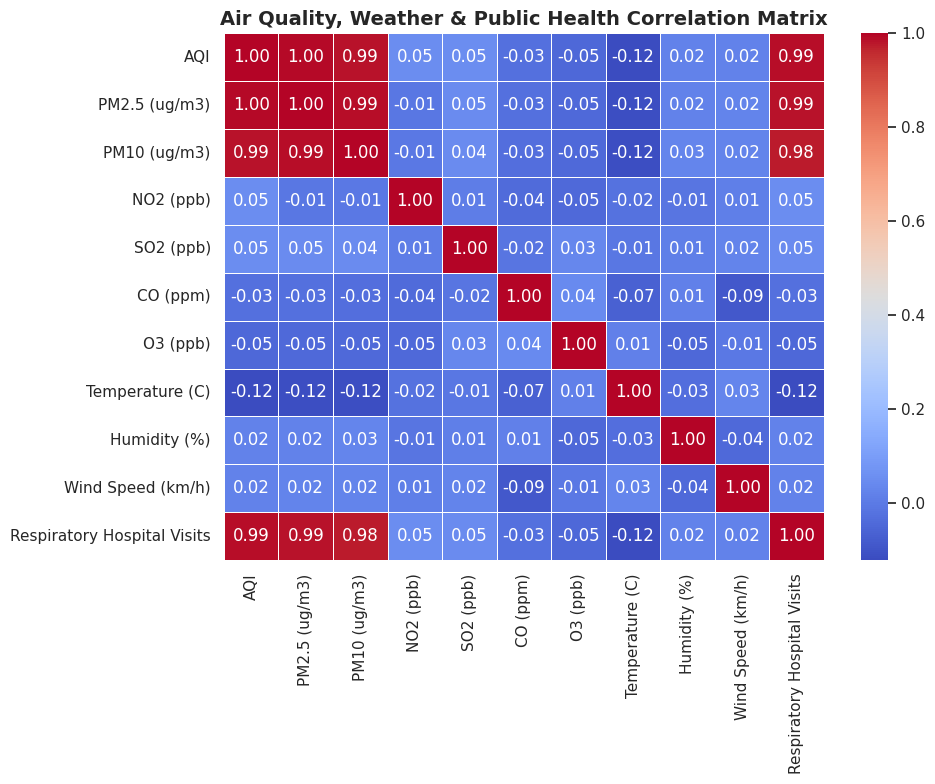

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# 1. Load Dataset
df = pd.read_csv("air_quality_analysis.csv")

# Convert Date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

# Display initial data structure
print("=== Dataset Summary ===")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

# 2. Air Quality Index (AQI) Trends Over Time Across Locations
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="Date", y="AQI", hue="Location", alpha=0.85, linewidth=1.5)
plt.title(
    "Air Quality Index (AQI) Trends Over Time across Locations",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=11)
plt.ylabel("AQI", fontsize=11)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3. Visualizing Relationships: AQI vs. Weather Conditions & Health Metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AQI vs. Temperature
sns.scatterplot(
    data=df,
    x="Temperature (C)",
    y="AQI",
    hue="Location",
    alpha=0.6,
    ax=axes[0],
)
axes[0].set_title("AQI vs. Temperature", fontsize=12, fontweight="bold")

# AQI vs. Wind Speed
sns.scatterplot(
    data=df,
    x="Wind Speed (km/h)",
    y="AQI",
    hue="Location",
    alpha=0.6,
    ax=axes[1],
)
axes[1].set_title("AQI vs. Wind Speed", fontsize=12, fontweight="bold")

# AQI vs. Public Health Metric (Respiratory Hospital Visits)
sns.regplot(
    data=df,
    x="AQI",
    y="Respiratory Hospital Visits",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[2],
)
axes[2].set_title(
    "AQI vs. Respiratory Hospital Visits", fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()

# 4. Correlation Heatmap between Air Quality, Weather, and Health Metrics
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=["float64", "int64"])
sns.heatmap(
    numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title(
    "Air Quality, Weather & Public Health Correlation Matrix",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()